**BANK MARKETING MACHINE LEARNING PROJECT**


In [17]:
#Import libraries
#imports the dataset and required libraries for data preprocessing, analysis, visualisation, and machine learning.
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    learning_curve,
    cross_val_score)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc)

import warnings
warnings.filterwarnings('ignore')

In [3]:
#Loading dataset for exploration and analysis
df = pd.read_csv("/home/bank.csv")

In [18]:
#to display and understand the structure of customer demographic, financial, and campaign-related variables.
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


In [19]:
#showing total number of rows and columns within the dataset
df.shape

(11162, 17)

In [20]:
#helps examine dataset structure and variable data types to understand feature composition and identify numerical and categorical variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  int64
 2   marital    11162 non-null  int64
 3   education  11162 non-null  int64
 4   default    11162 non-null  int64
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  int64
 7   loan       11162 non-null  int64
 8   contact    11162 non-null  int64
 9   day        11162 non-null  int64
 10  month      11162 non-null  int64
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  int64
 16  deposit    11162 non-null  int64
dtypes: int64(17)
memory usage: 1.4 MB


In [21]:
#this checks for Missing values to identify incomplete records that may affect model performance.
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [22]:
# check for duplicate customer records to ensure data consistency and avoid biased model training
df.duplicated().sum()

np.int64(0)

In [23]:
#remove duplicate rows to improve dataset quality and ensure unique customer observations
df.drop_duplicates(inplace=True)

In [4]:
#descriptive statistics are generated to understand distributions, variation, and central tendencies within numerical variables
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


## Exploratory Data Analysis (EDA)
This section explores customer characteristics, variable distributions, and relationships that may influence term deposit subscription behaviour.

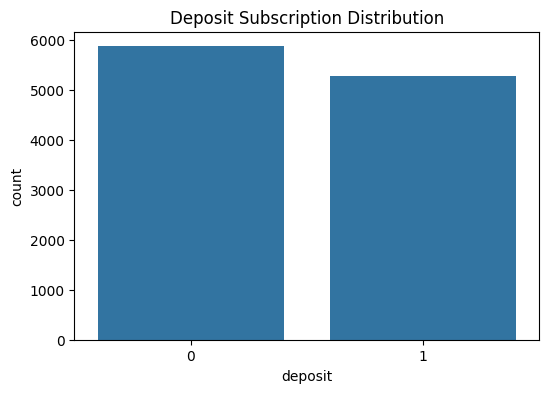

In [24]:
#Target Variable Distribution, this visualisation examines the distribution of subscription outcomes and identifies potential class imbalance
plt.figure(figsize=(6,4))
sns.countplot(x='deposit',data=df)
plt.title('Deposit Subscription Distribution')
plt.show()

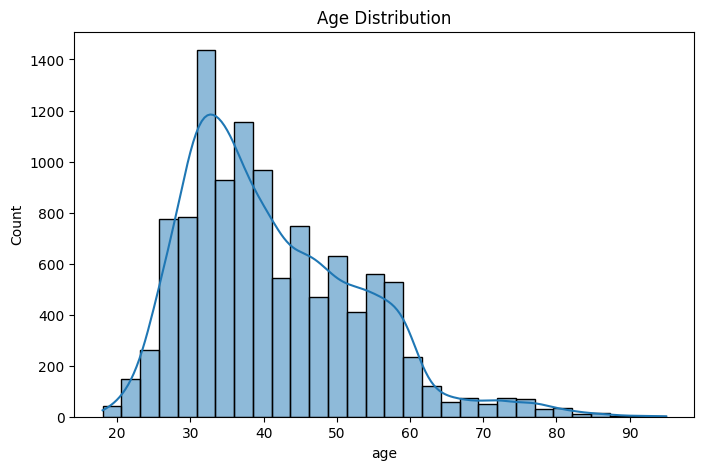

In [25]:
#Age Distribution
#This histogram explores the age characteristics of customers.
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

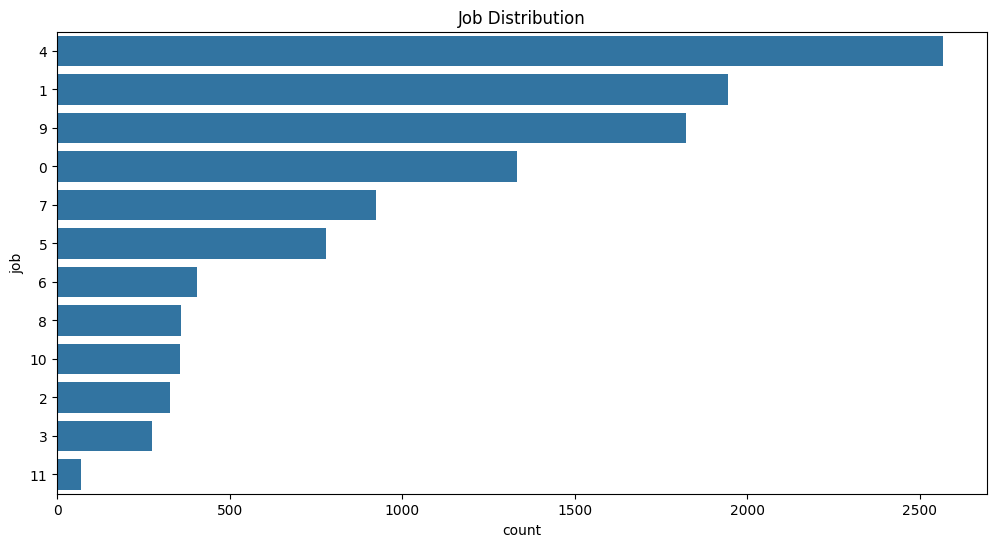

In [26]:
#Customer Occupation Distribution, this count plot examines occupation categories to understand customer socioeconomic characteristics
plt.figure(figsize=(12,6))
sns.countplot(y='job', data=df, order=df['job'].value_counts().index)
plt.title("Job Distribution")
plt.show()

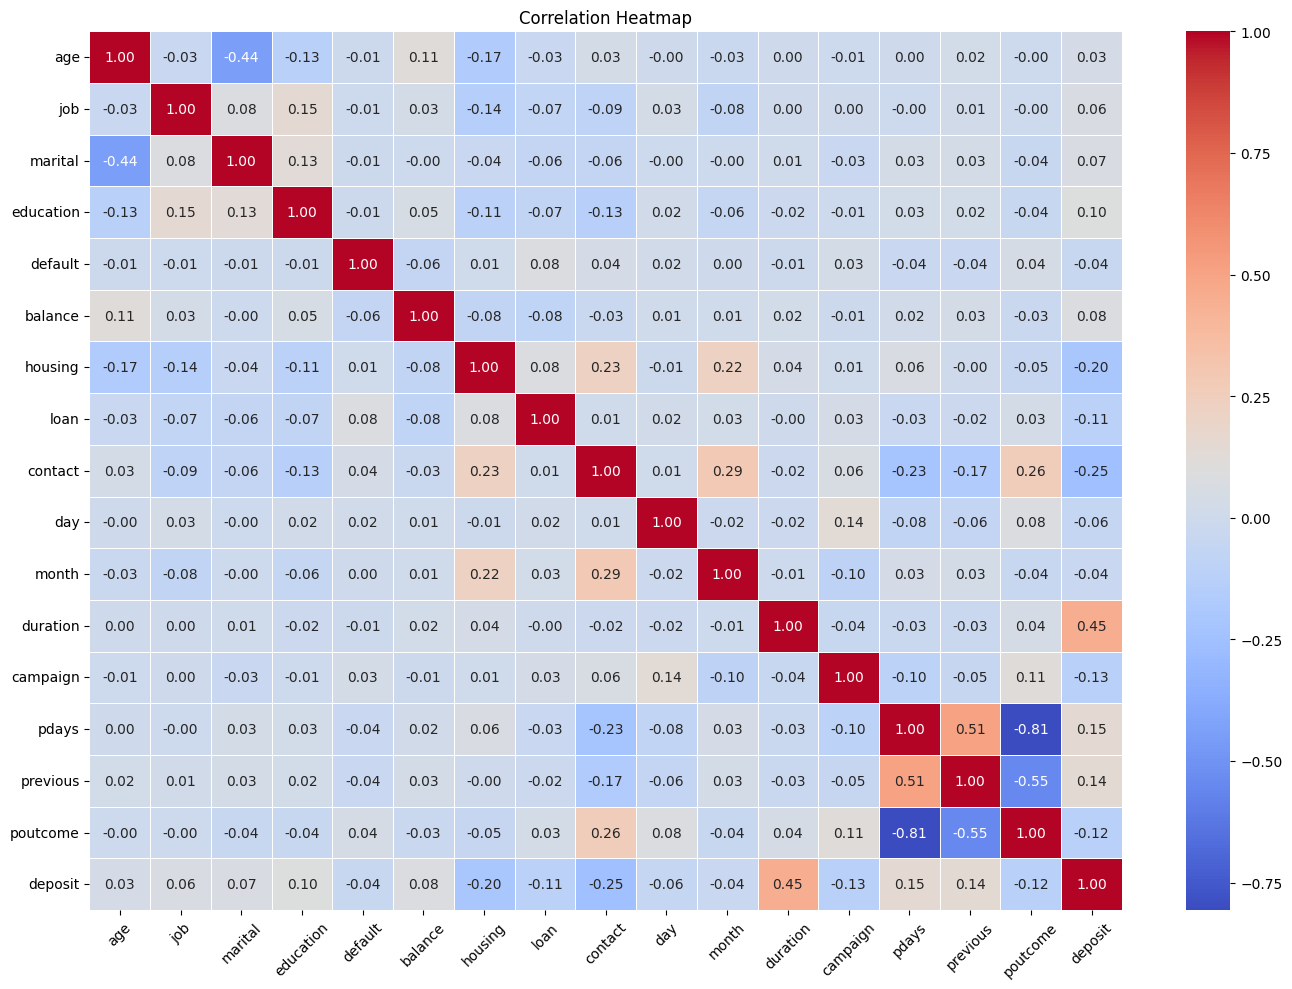

In [56]:
# Correlation heatmap for numerical variables

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt='.2f',      # rounds numbers to 2 decimal places
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

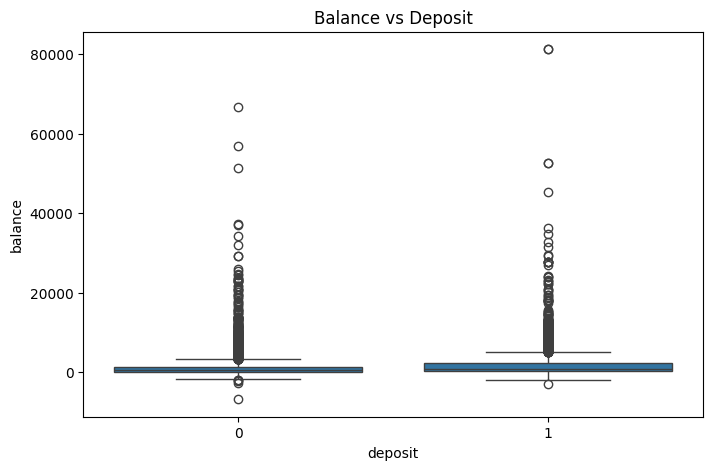

In [28]:
#Customer Balance and Subscription Relationship, this boxplot examines whether account balance differs between subscribers and non-subscribers
plt.figure(figsize=(8,5))
sns.boxplot(x='deposit',y='balance',data=df)
plt.title('Balance vs Deposit')
plt.show()

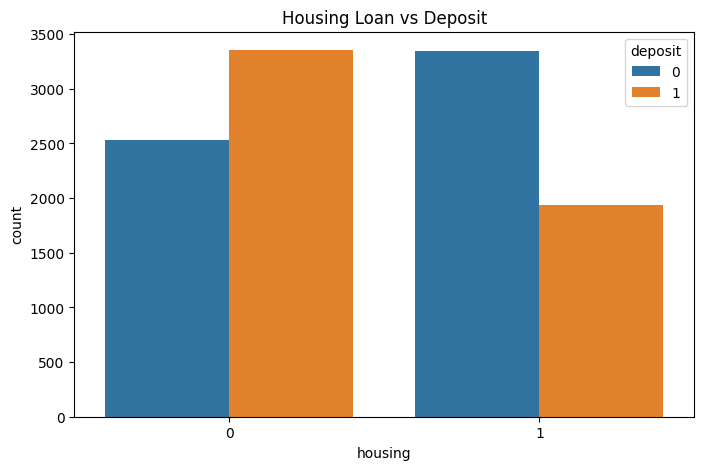

In [29]:
#Housing Loan Status and Subscription Behaviour, this visualisation explores the relationship between housing loan status and term deposit subscription outcomes
plt.figure(figsize=(8,5))
sns.countplot(x='housing',hue='deposit',data=df)
plt.title('Housing Loan vs Deposit')
plt.show()

 Data Preprocessing

This section prepares the dataset for machine learning through encoding, scaling, and train-test splitting.


In [30]:
## Label Encoding, Categorical variables are converted into numerical representations to ensure compatibility with machine learning algorithms
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

In [31]:
#features and Target
#Input features (X) and the target variable (y) are defined for supervised machine learning
X = df.drop('deposit', axis=1)
y = df['deposit']

In [32]:
#Train-Test Split to preserve class imbalance properly
#The dataset is divided into training and testing subsets using an 80:20 ratio to evaluate model generalisation.
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [33]:
#Feature Scaling
#Numerical features are standardised using StandardScaler to improve model performance, particularly for Logistic Regression
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Machine Learning Model Development

Logistic Regression Model

Logistic Regression is implemented as an interpretable baseline classification model.ION

In [34]:
#Logistic Regression Evaluation
#Model performance is assessed using accuracy, classification report, and confusion matrix.
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

In [35]:
lr_accuracy = accuracy_score(y_test, lr_predictions)
print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.7899686520376176


In [36]:
print(classification_report(y_test, lr_predictions))

              precision    recall  f1-score   support

           0       0.79      0.82      0.80      1166
           1       0.79      0.76      0.78      1067

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.79      0.79      0.79      2233



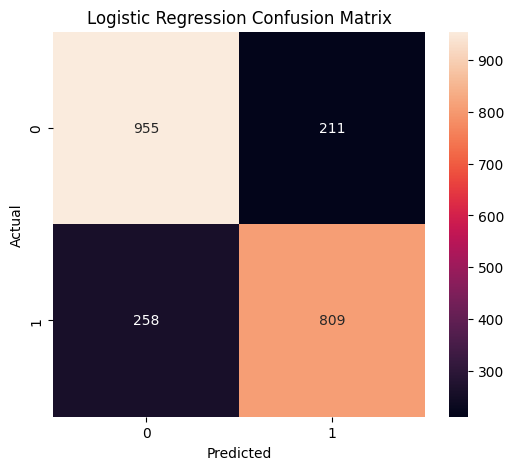

In [37]:
cm = confusion_matrix(y_test,lr_predictions)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [38]:
#Decison Tree
#Decision Tree is implemented to capture nonlinear relationships through hierarchical feature splitting
dt_model = DecisionTreeClassifier(max_depth=5,random_state=42)
dt_model.fit(X_train,y_train)
dt_predictions = dt_model.predict(X_test)

In [39]:
dt_predictions = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_predictions)
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.8051948051948052


In [40]:
# Decision Tree Evaluation
#Performance is evaluated using classification metrics and confusion matrix analysis
print(classification_report(y_test,dt_predictions))

              precision    recall  f1-score   support

           0       0.86      0.74      0.80      1166
           1       0.76      0.87      0.81      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.80      2233



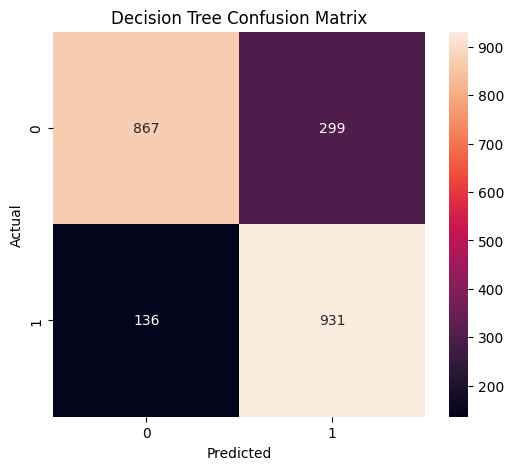

In [41]:
cm = confusion_matrix(y_test,dt_predictions)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [42]:
#Random Forest Classifier
#Random Forest is implemented as an ensemble learning model to improve predictive performance and reduce overfitting
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [43]:
#The model is evaluated using classification reports, confusion matrices, and predictive accuracy measures
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.825347066726377


In [44]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.85      0.80      0.83      1166
           1       0.80      0.85      0.82      1067

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233



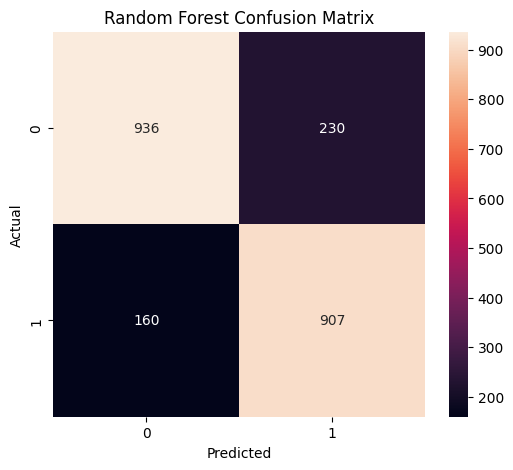

In [45]:
cm = confusion_matrix(y_test,rf_predictions)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [46]:
lr_accuracy = accuracy_score(y_test,lr_predictions)
print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.7899686520376176


In [47]:
dt_accuracy = accuracy_score(y_test,dt_predictions)
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.8051948051948052


In [48]:
rf_accuracy = accuracy_score(y_test,rf_predictions)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.825347066726377


**Model Comparison and Evaluation**

This section compares model performance using evaluation metrics, learning curves, ROC curves, and feature importance analysis

In [49]:
#Model Accuracy Comparison
#The predictive performance of all three models is compared using accuracy scores to identify the most effective classifier
models = ['Logistic Regression','Decision Tree','Random Forest']
accuracies = [lr_accuracy,dt_accuracy,rf_accuracy]
comparison = pd.DataFrame({'Model': models,'Accuracy': accuracies})

comparison

,Model,Accuracy
0,Logistic Regression,0.789969
1,Decision Tree,0.805195
2,Random Forest,0.825347


***Random Forest achieved the highest overall accuracy, indicating stronger predictive capability compared with Logistic Regression and Decision Tree.***

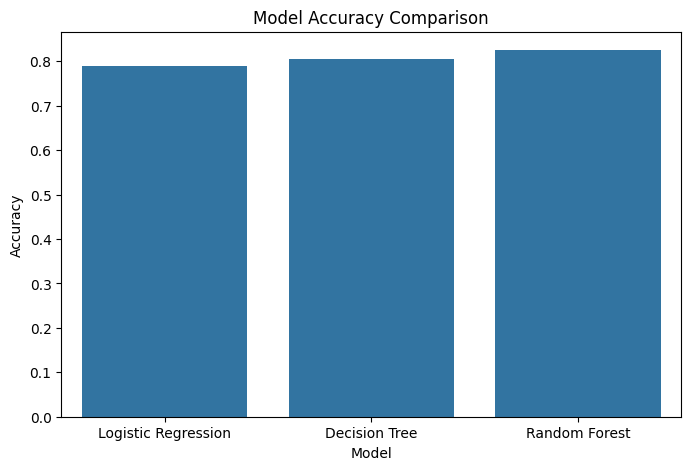

In [50]:
#Accuracy Comparison Visualisation
#A bar chart is used to visually compare the predictive accuracy of each machine learning model
plt.figure(figsize=(8,5))
sns.barplot(x='Model',y='Accuracy',data=comparison)
plt.title('Model Accuracy Comparison')
plt.show()

***The visual comparison highlights gradual improvement in performance across models, with Random Forest achieving the strongest overall predictive accuracy***

In [51]:
#Feature Importance Analysis
#Feature importance analysis identifies the variables that contributed most strongly to subscription prediction outcomes
feature_importance = pd.DataFrame({'Feature': X.columns,'Importance':rf_model.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance',ascending=False)

feature_importance

,Feature,Importance
11,duration,0.474949
10,month,0.072589
8,contact,0.064248
13,pdays,0.058158
0,age,0.053523
15,poutcome,0.050296
5,balance,0.047948
6,housing,0.040586
9,day,0.037476
14,previous,0.030763


***Variables such as campaign duration, account balance, age, and previous interactions exerted the strongest predictive influence, highlighting their practical importance for customer targeting strategies***

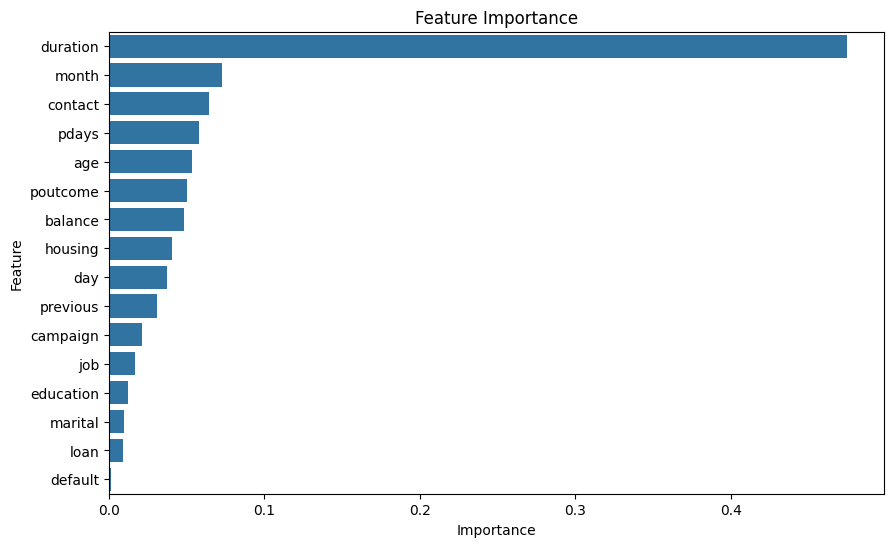

In [52]:
#feature Importance Graph
plt.figure(figsize=(10,6))
sns.barplot(x='Importance',y='Feature',data=feature_importance)
plt.title('Feature Importance')
plt.show()

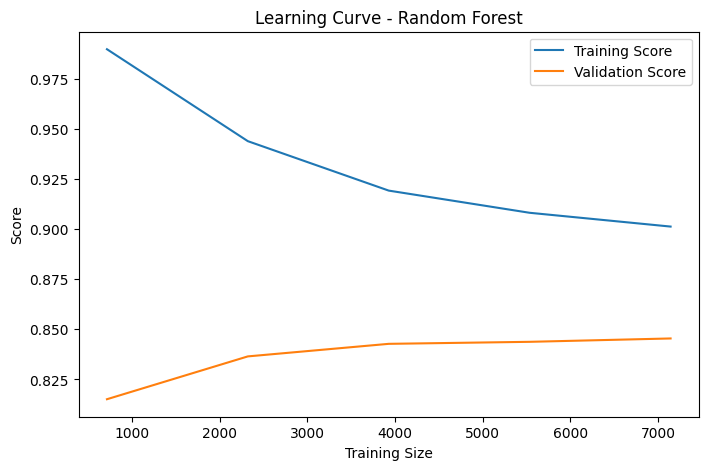

In [53]:
#Learning Curve Analysis
#Learning curves are used to assess model generalisation performance and identify potential overfitting or underfitting during training
train_sizes, train_scores, test_scores = learning_curve(rf_model,X_train,y_train,cv=5)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes,train_mean,label='Training Score')
plt.plot(train_sizes,test_mean,label='Validation Score')

plt.title('Learning Curve - Random Forest')
plt.xlabel('Training Size')
plt.ylabel('Score')

plt.legend()
plt.show()

***The Random Forest learning curve demonstrated relatively stable convergence between training and validation performance, suggesting strong generalisation capability and minimal overfitting***

In [54]:
#Cross Validation
cv_scores = cross_val_score(rf_model,X_train,y_train,cv=5 )
print("Cross Validation Score:", cv_scores.mean())

Cross Validation Score: 0.8454477244425205


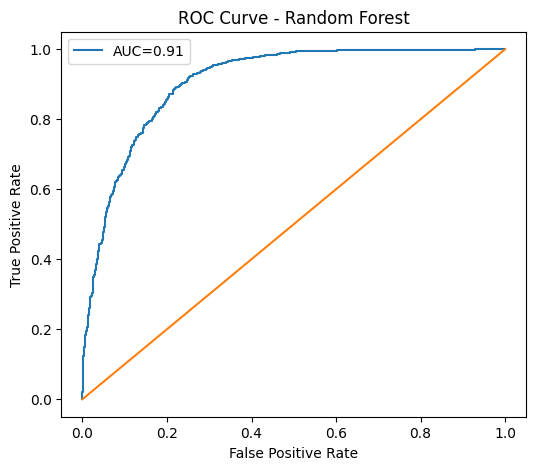

In [55]:
#ROC Curve Analysis
#Receiver Operating Characteristic (ROC) curves evaluate classification performance by examining the trade-off between true positive rate and false positive rate across different threshold values
y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test,y_prob)
roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label=f'AUC={roc_auc:.2f}')

plt.plot([0,1],[0,1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

***Random Forest achieved the strongest ROC performance and highest AUC score, demonstrating superior ability to distinguish between subscribing and non-subscribing customers***